# Image Processing with OpenCV

**OpenCV** (Open Source Computer Vision Library) is the industry standard for image and video processing. 

**Important Jupyter Note:** The standard OpenCV functions to display images (`cv2.imshow()`, `cv2.waitKey()`) open new UI windows that frequently crash or hang Jupyter Notebooks. Therefore, we will use **Matplotlib** to display our images inline.

## 1. Setup and the BGR vs. RGB Trap

OpenCV reads and represents images as NumPy arrays. However, for historical reasons, OpenCV reads color channels in **BGR (Blue, Green, Red)** order, whereas almost every other library (including Matplotlib) uses **RGB**. 

We must convert the color space before displaying.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to safely display images in Jupyter
def display_img(title, img, is_bgr=True):
    plt.figure(figsize=(6, 4))
    plt.title(title)
    if is_bgr:
        # Convert BGR to RGB for Matplotlib
        img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_display)
    else:
        # Display as grayscale
        plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

print("OpenCV Version:", cv2.__version__)

OpenCV Version: 4.12.0


## 2. Loading / Creating an Image

Normally, you load an image using `img = cv2.imread('path/to/image.jpg')`. 

To make this notebook run without external files, we will create a synthetic image using a blank NumPy array and draw on it.

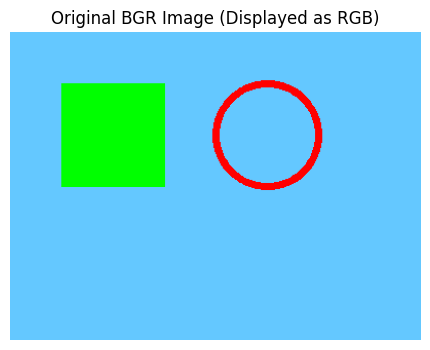

In [2]:
# Create a 300x400 image with 3 color channels (BGR), filled with zeros (black)
image = np.zeros((300, 400, 3), dtype=np.uint8)

# Fill the background with a light blue color (BGR format: Blue=255, Green=200, Red=100)
image[:] = (255, 200, 100)

# Draw some shapes to make it interesting
# cv2.rectangle(img, top_left, bottom_right, color_bgr, thickness)
cv2.rectangle(image, (50, 50), (150, 150), (0, 255, 0), -1)  # -1 means filled

# cv2.circle(img, center, radius, color_bgr, thickness)
cv2.circle(image, (250, 100), 50, (0, 0, 255), 5)  # Red outline

display_img("Original BGR Image (Displayed as RGB)", image)

## 3. Grayscale and Color Transforms

Many computer vision algorithms (like edge detection or face recognition) work on grayscale images because color information is often unnecessary and processing 1 channel is 3x faster than 3 channels.

Original Shape: (300, 400, 3)
Grayscale Shape: (300, 400)


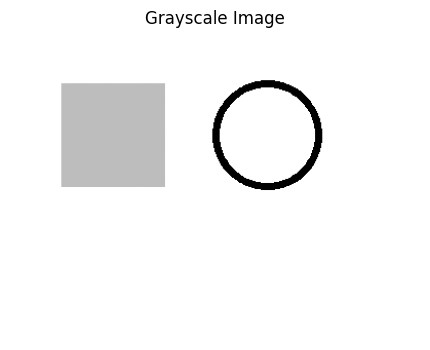

In [3]:
# Convert the image from BGR to Grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Original Shape:", image.shape)      # (300, 400, 3)
print("Grayscale Shape:", gray_image.shape) # (300, 400)

display_img("Grayscale Image", gray_image, is_bgr=False)

## 4. Blurring and Smoothing

Images often have noise. We use blurring (like a Gaussian Blur) to smooth the image out before applying more complex algorithms. It acts as a low-pass filter.

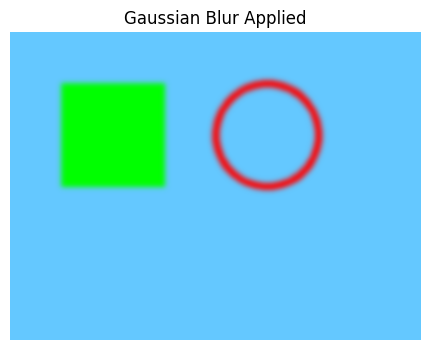

In [4]:
# Apply a Gaussian blur
# The tuple (15, 15) is the kernel size (must be odd numbers)
# The '0' is the standard deviation in the X direction (0 means auto-calculate)
blurred_image = cv2.GaussianBlur(image, (15, 15), 0)

display_img("Gaussian Blur Applied", blurred_image)

## 5. Edge Detection (Canny)

The Canny Edge Detector is a popular algorithm to find the boundaries of objects within images. It works by looking for areas of high contrast (rapid changes in intensity).

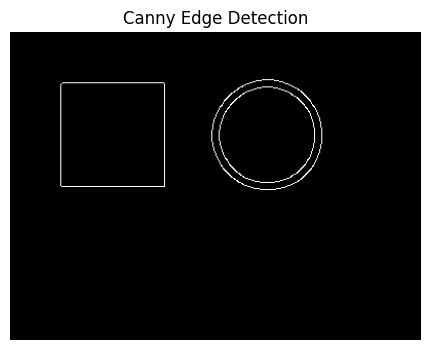

In [5]:
# Canny expects a grayscale or blurred image, and two thresholds.
# Any gradient value larger than threshold2 is an edge.
# Any value below threshold1 is not an edge.
# Values in between are classified based on connectivity.
edges = cv2.Canny(gray_image, threshold1=50, threshold2=150)

display_img("Canny Edge Detection", edges, is_bgr=False)

## 6. Writing Text on Images

Finally, OpenCV provides a built-in method to overlay text. This is highly useful for labeling objects after detecting them.

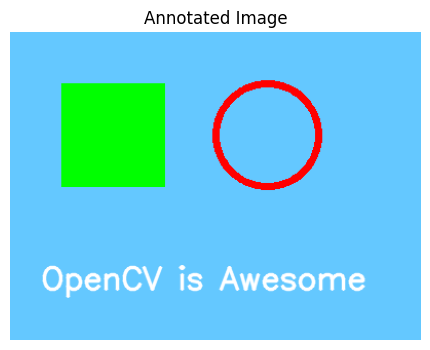

In [6]:
# Create a copy of the original so we don't permanently alter it
annotated_image = image.copy()

font = cv2.FONT_HERSHEY_SIMPLEX
text = "OpenCV is Awesome"
position = (30, 250)    # Bottom left corner (X, Y)
font_scale = 1
color = (255, 255, 255) # White (BGR)
thickness = 2

cv2.putText(annotated_image, text, position, font, font_scale, color, thickness, cv2.LINE_AA)

display_img("Annotated Image", annotated_image)